<a href="https://colab.research.google.com/github/duanfafner/haruandchar/blob/main/Censored_and_Count_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SU25:Data Analytics For Business

Homework 2 - Part 1 Censored Models

Dataset: Mobile data usage

In [1]:
library(readr)
library(dplyr)
library(ggplot2)
library(tidyverse)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
mobile_data <- read.csv("Mobile_data_usage.csv")
summary(mobile_data)
head(mobile_data, 10)

   CustomerID        DataUse              Quota             Days   
 Min.   :   1.0   Min.   :  0.00000   Min.   :  0.00   Min.   : 1  
 1st Qu.: 250.8   1st Qu.:  0.02548   1st Qu.: 29.11   1st Qu.: 8  
 Median : 500.5   Median :  0.53058   Median : 59.76   Median :16  
 Mean   : 500.5   Mean   :  1.66582   Mean   : 62.65   Mean   :16  
 3rd Qu.: 750.2   3rd Qu.:  1.86610   3rd Qu.: 89.91   3rd Qu.:24  
 Max.   :1000.0   Max.   :136.68000   Max.   :600.00   Max.   :31  

,CustomerID,DataUse,Quota,Days
,<int>,<dbl>,<dbl>,<int>
1,1,2.4321,100.000,31
2,1,0.0000,97.568,30
3,1,0.0000,97.568,29
4,1,0.0000,97.568,28
5,1,0.0000,97.568,27
6,1,0.0000,97.568,26
7,1,0.0000,97.568,25
8,1,0.0000,97.568,24
9,1,0.0000,97.568,23


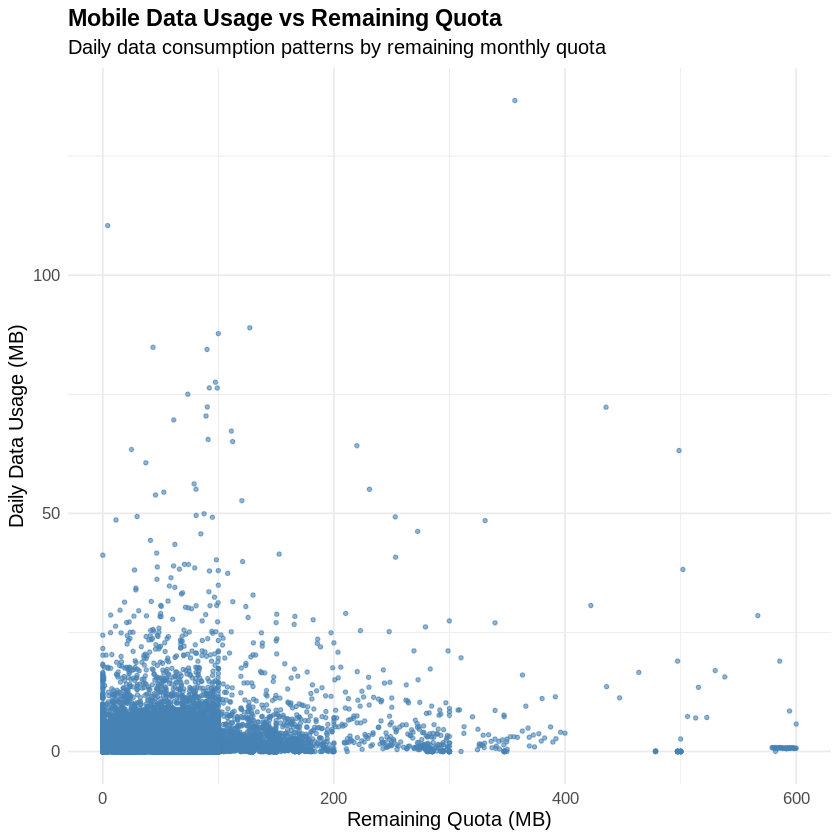

In [3]:
# Create scatter plot with DataUse on y-axis and Quota on x-axis
scatter_plot <- ggplot(mobile_data, aes(x = Quota, y = DataUse)) +
  geom_point(alpha = 0.6, size = 0.9, color = "steelblue") +
  labs(title = "Mobile Data Usage vs Remaining Quota",
       subtitle = "Daily data consumption patterns by remaining monthly quota",
       x = "Remaining Quota (MB)",
       y = "Daily Data Usage (MB)") +
  theme_minimal() +
  theme(plot.title = element_text(size = 14, face = "bold"),
        plot.subtitle = element_text(size = 12),
        axis.title = element_text(size = 12),
        axis.text = element_text(size = 10))

# Display the plot
print(scatter_plot)


The scatter plot will show heteroscedasticity - the spread (variance) of data usage increases as the remaining quota increases. This fan-shaped pattern violates the constant variance assumption of linear regression, requiring special treatment like weighted least squares, robust standard errors, or transformation of variables.

In [4]:
linear_model <- lm(DataUse ~ Quota + Days, data = mobile_data)

# Display the regression summary
summary(linear_model)


Call:
lm(formula = DataUse ~ Quota + Days, data = mobile_data)

Residuals:
    Min      1Q  Median      3Q     Max 
 -5.915  -1.492  -1.079   0.215 132.658 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.3633019  0.0476447  28.614  < 2e-16 ***
Quota        0.0079765  0.0004577  17.426  < 2e-16 ***
Days        -0.0123239  0.0025276  -4.876 1.09e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.817 on 30997 degrees of freedom
Multiple R-squared:  0.009702,	Adjusted R-squared:  0.009638 
F-statistic: 151.8 on 2 and 30997 DF,  p-value: < 2.2e-16


In [5]:
install.packages("censReg")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘collapse’, ‘lmtest’, ‘Rdpack’, ‘maxLik’, ‘sandwich’, ‘miscTools’, ‘plm’




In [6]:
library(censReg)

Loading required package: maxLik

Loading required package: miscTools


Please cite the 'maxLik' package as:
Henningsen, Arne and Toomet, Ott (2011). maxLik: A package for maximum likelihood estimation in R. Computational Statistics 26(3), 443-458. DOI 10.1007/s00180-010-0217-1.

If you have questions, suggestions, or comments regarding the 'maxLik' package, please use a forum or 'tracker' at maxLik's R-Forge site:
https://r-forge.r-project.org/projects/maxlik/


Please cite the 'censReg' package as:
Henningsen, Arne (2017). censReg: Censored Regression (Tobit) Models. R package version 0.5. http://CRAN.R-Project.org/package=censReg.

If you have questions, suggestions, or comments regarding the 'censReg' package, please use a forum or 'tracker' at the R-Forge site of the 'sampleSelection' project:
https://r-forge.r-project.org/projects/sampleselection/



In [7]:
tobit_model <- censReg(DataUse ~ Quota + Days,
                       data = mobile_data,
                       left = 0)

In [8]:
summary(tobit_model)


Call:
censReg(formula = DataUse ~ Quota + Days, left = 0, data = mobile_data)

Observations:
         Total  Left-censored     Uncensored Right-censored 
         31000           6536          24464              0 

Coefficients:
              Estimate Std. error t value  Pr(> t)    
(Intercept)  0.6111869  0.0576965  10.593  < 2e-16 ***
Quota        0.0090140  0.0005516  16.340  < 2e-16 ***
Days        -0.0119462  0.0030650  -3.898 9.71e-05 ***
logSigma     1.4947160  0.0046189 323.611  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Newton-Raphson maximisation, 7 iterations
Return code 8: successive function values within relative tolerance limit (reltol)
Log-likelihood: -76375.86 on 4 Df


In [9]:
# First, calculate the mean of Days in the sample
mean_days <- mean(mobile_data$Days)
cat("Mean of Days in the sample:", round(mean_days, 4), "\n\n")

# Compute marginal effects at two different X values
# Note: xValues should include intercept (1), Quota, and Days in that order

# (i) Marginal effect when Quota = 10, Days = mean of Days
cat("=== Marginal Effects at Quota = 10, Days = mean ===\n")
margeff_quota10 <- margEff(tobit_model,
                           xValues = c(1, 10, mean_days))
print(margeff_quota10)

Mean of Days in the sample: 16 

=== Marginal Effects at Quota = 10, Days = mean ===
       Quota         Days 
 0.004917625 -0.006517316 


In [10]:
cat("=== Marginal Effects at Quota = 2000, Days = mean ===\n")
margeff_quota2000 <- margEff(tobit_model,
                             xValues = c(1, 2000, mean_days))
print(margeff_quota2000)

=== Marginal Effects at Quota = 2000, Days = mean ===
       Quota         Days 
 0.009013811 -0.011945981 


Homework 2 – Part 2
Count Models


In [11]:

forum_data <- read.csv("Forum_Posts.csv")

In [12]:
# Regressing posts on all other explanatory variables
poisson_model <- glm(posts ~ totalPosts + readingRate + postStock + wknd,
                      family = poisson,
                      data = forum_data
                 )

In [13]:
summary(poisson_model)


Call:
glm(formula = posts ~ totalPosts + readingRate + postStock + 
    wknd, family = poisson, data = forum_data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.744e+00  5.193e-01  -9.135  < 2e-16 ***
totalPosts   7.963e-06  1.238e-06   6.433 1.25e-10 ***
readingRate  1.125e-01  4.963e-02   2.266   0.0235 *  
postStock    6.735e-03  4.733e-03   1.423   0.1548    
wknd        -8.691e-02  4.127e-02  -2.106   0.0352 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 20863  on 11999  degrees of freedom
Residual deviance: 20762  on 11995  degrees of freedom
AIC: 25459

Number of Fisher Scoring iterations: 6


In [14]:
# Step 2: Extract the residual deviance and degrees of freedom
residual_deviance <- poisson_model$deviance
df_residual <- poisson_model$df.residual


In [15]:
y <- forum_data$posts
yhat <- predict(poisson_model, type="response")
sum((y-yhat)^2/yhat)/(nrow(forum_data)-length(coef(poisson_model)))
# disperse statsitcs
# significant overdispersion and will need negative binomial model

[1] 5.168645

In [16]:
library(MASS)
nb_model <- glm.nb(posts ~ totalPosts + readingRate + postStock + wknd,
                   data = forum_data)


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




In [17]:
summary(nb_model)


Call:
glm.nb(formula = posts ~ totalPosts + readingRate + postStock + 
    wknd, data = forum_data, init.theta = 0.1154693143, link = log)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.608e+00  1.103e+00  -4.178 2.94e-05 ***
totalPosts   7.539e-06  2.560e-06   2.945  0.00323 ** 
readingRate  1.150e-01  1.044e-01   1.101  0.27075    
postStock    6.864e-03  1.013e-02   0.678  0.49803    
wknd        -8.655e-02  8.568e-02  -1.010  0.31243    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(0.1155) family taken to be 1)

    Null deviance: 4854.1  on 11999  degrees of freedom
Residual deviance: 4831.3  on 11995  degrees of freedom
AIC: 16309

Number of Fisher Scoring iterations: 1


              Theta:  0.11547 
          Std. Err.:  0.00402 

 2 x log-likelihood:  -16297.14900 

Theta is the dispersion parameter in the negative binomial distribution. It controls how much extra variance there is beyond what Poisson would predict:

Larger θ = less overdispersion (closer to Poisson)
Smaller θ = more overdispersion
θ → ∞ = approaches Poisson distribution
θ close to 0 = high overdispersion

In [18]:
# prompt: how to calcualte bic of the poisson_model and bic of nb_model

# Calculate BIC for Poisson model
bic_poisson <- BIC(poisson_model)
cat("BIC for Poisson model:", round(bic_poisson, 4), "\n")

# Calculate BIC for Negative Binomial model
bic_nb <- BIC(nb_model)
cat("BIC for Negative Binomial model:", round(bic_nb, 4), "\n")

# Note: A lower BIC generally indicates a better model. You can compare these values
# to see which model is preferred based on the Bayesian Information Criterion.

BIC for Poisson model: 25495.8 
BIC for Negative Binomial model: 16353.5 


AIC: Penalty stays constant regardless of sample size
BIC: Penalty gets stronger as sample size increases

AIC:

Goal: Minimize prediction error
Philosophy: Find the model that best predicts new data
Tends to: Select more complex models
Best for: Prediction tasks

BIC:

Goal: Find the "true" model
Philosophy: Assumes one true model exists in your candidate set
Tends to: Select simpler models (more conservative)
Best for: Model selection and scientific inference

In [19]:
xbar <-colMeans(forum_data)[2:5]
xb.pos <- crossprod(coef(poisson_model),c(1,xbar))
xb.nb <- crossprod(coef(nb_model),c(1,xbar))

In [20]:
k <-0:20
p1 <- dpois(k, exp(xb.pos))
p2 <- dnbinom(k, size=nb_model$theta, mu=exp(xb.nb))


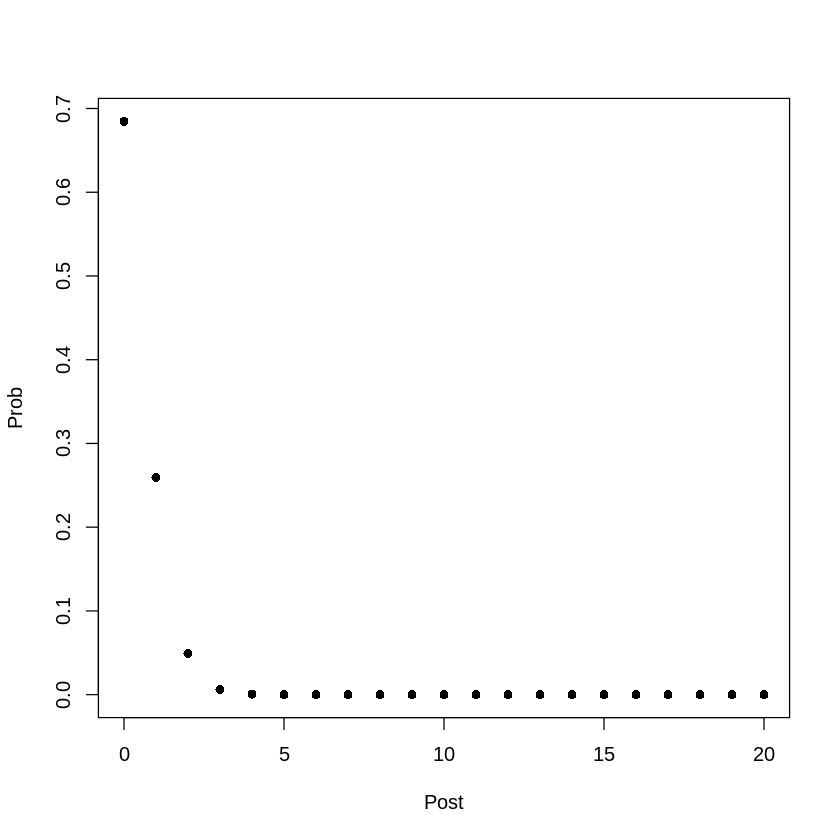

In [21]:
plot(k,p1,pch=16,xlab="Post", ylab="Prob")

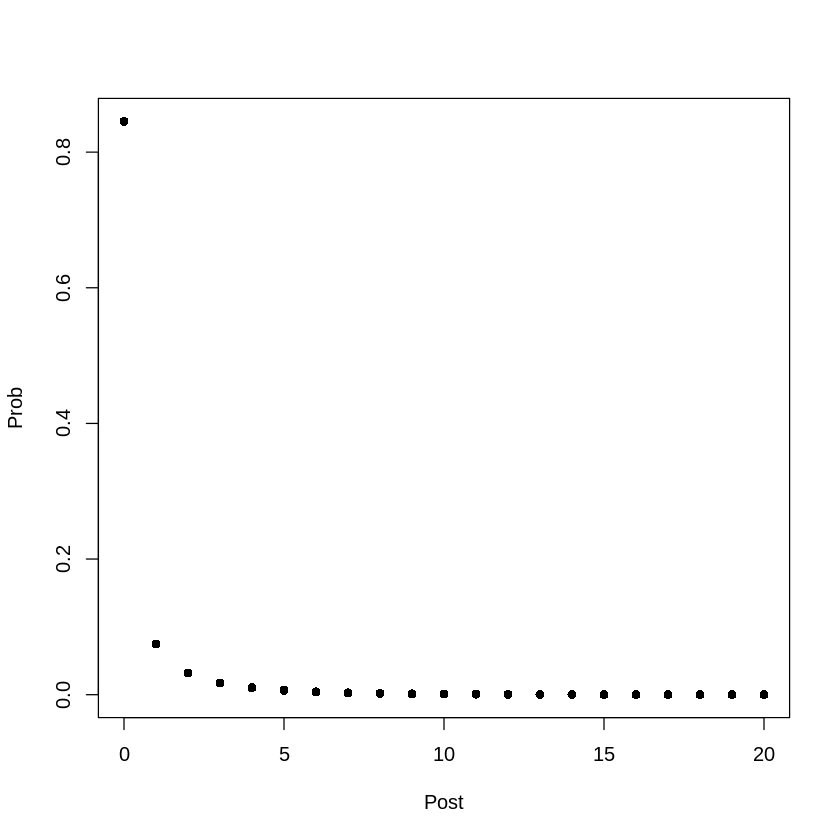

In [22]:
plot(k,p2,pch=16,xlab="Post", ylab="Prob")

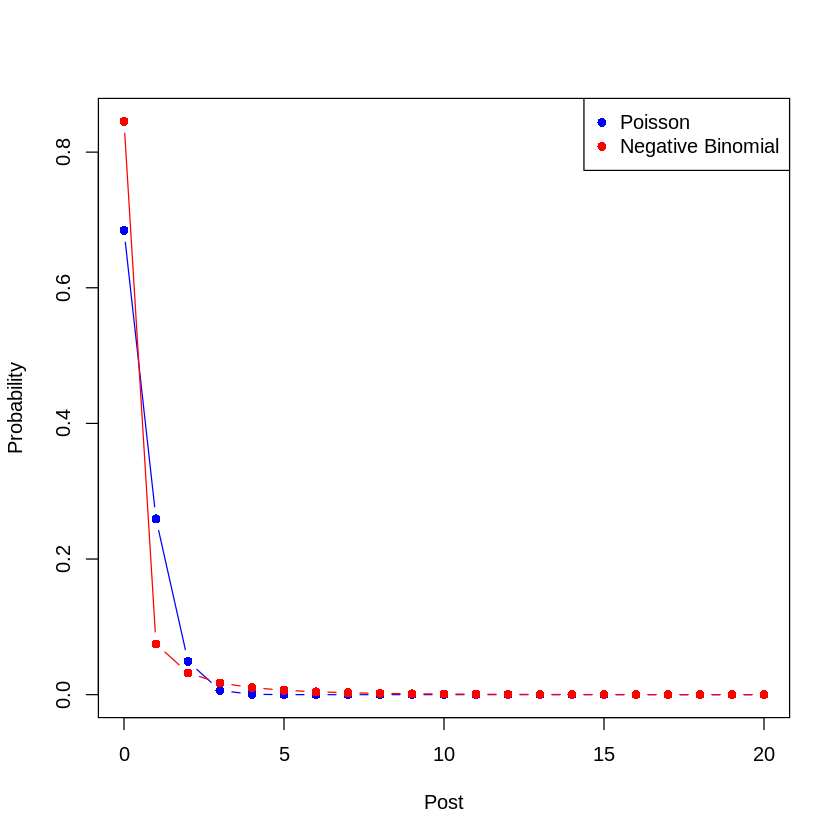

In [23]:
# prompt: i want to combine the above two charts: poisson and negative binomial into one chart

plot(k, p1, pch = 16, xlab = "Post", ylab = "Probability", type = "b", col = "blue", ylim = c(0, max(p1, p2)))
lines(k, p2, pch = 16, type = "b", col = "red")
legend("topright", legend = c("Poisson", "Negative Binomial"), col = c("blue", "red"), pch = 16)

In [24]:
# prompt: what does the dpois() function generate?

# The dpois() function in R generates the probability density function (or more accurately, the probability mass function) for the Poisson distribution.
# Specifically, dpois(x, lambda) calculates the probability of observing exactly 'x' events in a fixed interval of time or space, given that the events occur with an average rate of 'lambda' per interval.
# In your code, `dpois(k, exp(xb.pos))` calculates the probability of observing `k` posts according to the Poisson model's prediction, where `exp(xb.pos)` is the expected number of posts based on the linear predictor `xb.pos`.

In [25]:
# prompt: what is the chart trying to explain the difference between the two model

# The final chart is trying to explain the difference in the predicted probability distributions of the number of posts between the Poisson and Negative Binomial models.
#
# - The x-axis (`k`) represents the number of posts (from 0 to 20).
# - The y-axis (`Probability`) represents the predicted probability of observing that number of posts.
# - The blue line (`Poisson`) shows the predicted probabilities from the Poisson model.
# - The red line (`Negative Binomial`) shows the predicted probabilities from the Negative Binomial model.
#
# By comparing the shapes and values of the blue and red lines, the chart visually demonstrates how the Negative Binomial model, which accounts for overdispersion (extra variability not explained by the mean), provides a different probability distribution compared to the Poisson model. The note about overdispersion earlier in the code suggests that the Negative Binomial model is expected to fit the data better if there is significant overdispersion. The plot visually supports this by showing how the distributions differ, likely with the Negative Binomial having heavier tails (higher probability for extreme values) than the Poisson distribution, which is a characteristic of overdispersed count data.

In [26]:
# prompt: which of the following statements is the most appropriate about the difference between the probability distributions from the two models?

# Looking at the final plot, the Negative Binomial distribution (red line) appears flatter and has heavier tails (assigns higher probability to larger counts of posts) than the Poisson distribution (blue line). This is characteristic of a model that accounts for overdispersion, which was suggested by the overdispersion test earlier (sum((y-yhat)^2/yhat)/(nrow(forum_data)-length(coef(poisson_model))).
#
# Statement: "The Negative Binomial distribution is more dispersed than the Poisson distribution."
#
# This is the most appropriate statement because the visual difference in the plot directly reflects the effect of overdispersion. The Negative Binomial model, with its additional parameter (theta), allows for the variance to be greater than the mean, resulting in a more spread-out distribution compared to the Poisson distribution, where the mean and variance are equal by definition. The plot clearly shows the Negative Binomial assigning higher probability to counts further away from the mean (heavier tails) and lower probability to the most frequent counts near the mean compared to the Poisson model.